#Tokenization & Embeddings

In [1]:
sentence = "The cat sat on the mat"

tokens = sentence.lower().split()

print("Sentence:", sentence)
print("Tokens  :", tokens)

Sentence: The cat sat on the mat
Tokens  : ['the', 'cat', 'sat', 'on', 'the', 'mat']


#Vocabulary and Token ID's

In [2]:
vocab = {word: idx for idx, word in enumerate(set(tokens))}

token_ids = [vocab[t] for t in tokens]

print("Vocabulary:", vocab)
print("Token IDs :", token_ids)

Vocabulary: {'the': 0, 'sat': 1, 'mat': 2, 'cat': 3, 'on': 4}
Token IDs : [0, 3, 1, 4, 0, 2]


#Embeddings

In [5]:
import numpy as np

np.random.seed(42)
EMBED_DIM = 4

embedding_table = {word: np.random.randn(EMBED_DIM) for word in vocab}

print("Embeddings for each token:\n")
for token in tokens:
    vec = embedding_table[token]
    print(f"  {token:<6} → {vec.round(2)}")

Embeddings for each token:

  the    → [ 0.5  -0.14  0.65  1.52]
  cat    → [ 0.24 -1.91 -1.72 -0.56]
  sat    → [-0.23 -0.23  1.58  0.77]
  on     → [-1.01  0.31 -0.91 -1.41]
  the    → [ 0.5  -0.14  0.65  1.52]
  mat    → [-0.47  0.54 -0.46 -0.47]


#Cosine Similarity

In [6]:
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

word_vecs = {
    "cat":  np.array([0.9, 0.1, 0.2, 0.0]),
    "dog":  np.array([0.8, 0.2, 0.2, 0.0]),
    "mat":  np.array([0.1, 0.9, 0.1, 0.0]),
    "sat":  np.array([0.1, 0.8, 0.2, 0.0]),
    "king": np.array([0.0, 0.1, 0.9, 0.8]),
}

pairs = [("cat", "dog"), ("cat", "king"), ("mat", "sat")]

print("Cosine Similarity:\n")
for w1, w2 in pairs:
    sim = cosine_similarity(word_vecs[w1], word_vecs[w2])
    print(f"  {w1} ↔ {w2}  →  {sim:.2f}")

Cosine Similarity:

  cat ↔ dog  →  0.99
  cat ↔ king  →  0.17
  mat ↔ sat  →  0.99


#Visualiza Embeddings

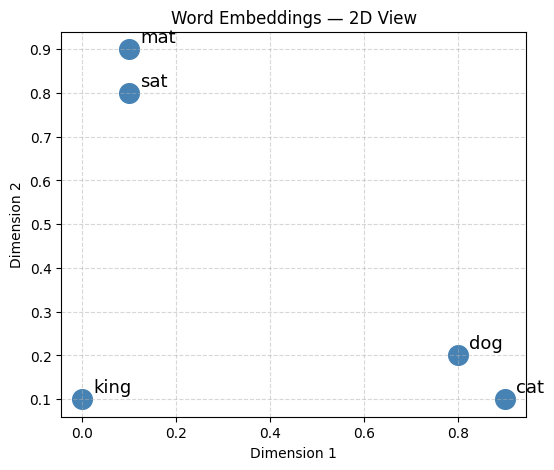

cat & dog are close → similar meaning!
king is far away   → different meaning!


In [12]:
import matplotlib.pyplot as plt

words = list(word_vecs.keys())

x = [word_vecs[w][0] for w in words]
y = [word_vecs[w][1] for w in words]

plt.figure(figsize=(6, 5))
plt.scatter(x, y, color='steelblue', s=200)

for i, word in enumerate(words):
    plt.annotate(word, (x[i], y[i]),
                 textcoords='offset points',
                 xytext=(8, 5), fontsize=13)

plt.title("Word Embeddings — 2D View")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("cat & dog are close → similar meaning!")
print("king is far away   → different meaning!")